In [20]:
%pip install qiskit==1.2.4
%pip install qiskit-aer==0.15.1
%pip install pylatexenc==2.10

from qiskit import QuantumCircuit
from qiskit.converters import circuit_to_gate
from qiskit.visualization import array_to_latex
from qiskit.quantum_info import Operator
from qiskit.quantum_info import Statevector
from qiskit import transpile
from qiskit.providers.basic_provider import BasicSimulator
from qiskit.visualization import plot_histogram

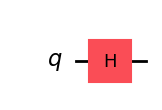

In [21]:

# Create a circuit with one qubit
circuit = QuantumCircuit(1)

# Add a Hadamard (H) gate on qubit 0, to create a superposition
circuit.h(0)

# Draw the circuit diagram. Delete "mpl" to get a text diagram.
circuit.draw("mpl")

In [22]:
# Now simulate the circuit by calculating the effect on state vectors.
# Set the initial state of the simulator to |0>
# The state vector has two coefficients, both 0
state = Statevector.from_int(0, 2)

# Apply the circuit to the state
state = state.evolve(circuit)

# Display using latex. This requires the pylatexenc module.
# Omit "latex" to get a numerical (not algebraic) view of the state vector.
state.draw("latex")

<IPython.core.display.Latex object>

In [23]:
# A different way of dislaying the state, again using latex
from qiskit.visualization import array_to_latex

array_to_latex(state)

<IPython.core.display.Latex object>

In [24]:
# The whole circuit is a unitary operator, which we can display.

U = Operator(circuit)
array_to_latex(U)

<IPython.core.display.Latex object>

In [25]:
# Or less beautifully:
U.data
# The format is a little bit odd. 0.j means the imaginary part is 0
# 0 is being displayed with a decimal point but no trailing 0
# j is used for the square root of -1, instead of i

array([[ 0.70710678+0.j,  0.70710678+0.j],
       [ 0.70710678+0.j, -0.70710678+0.j]])

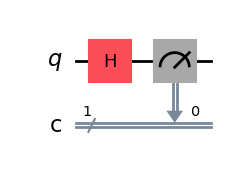

In [26]:
# Now reconstruct the circuit and add a measurement
# The second parameter of QuantumCircuit is the number of classical bits
circuit = QuantumCircuit(1,1)
circuit.h(0)

# The first list is the qubits to measure,
# the second list is the classical bits where the results go
circuit.measure([0],[0])
circuit.draw("mpl")

In [27]:
# We will need to transpile the circuit into QASM instructions for the back end

# Use BasicSimulator
backend = BasicSimulator()

# Compile / transpile
qc_compiled = transpile(circuit, backend)

# Run the circuit on the simulator.
# We've set the number of repeats of the circuit
# to be 1024, which is the default.
# The qubits start in state |0>
job_sim = backend.run(qc_compiled, shots=1024)

# Grab the results from the job (this doesn't produce any output).
result_sim = job_sim.result()

In [28]:
# The simplest way to see the results of the simulation
counts = result_sim.get_counts(qc_compiled)
print(counts)

# The results are not exactly half 0 and half 1, but should be close.
# There will be different results each time the previous cell is run.

{'1': 505, '0': 519}


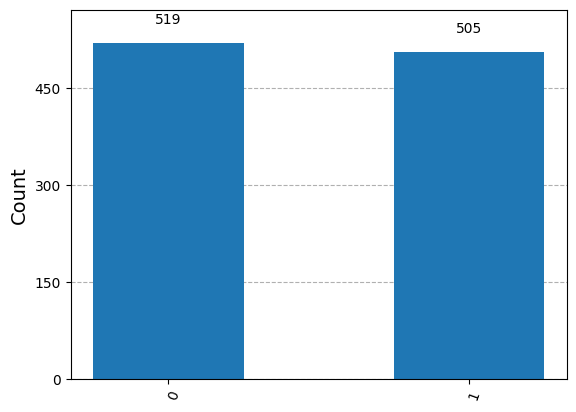

In [29]:
# We can also produce a graph

plot_histogram(counts)

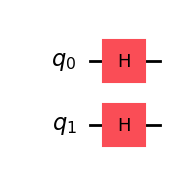

In [30]:
# Now let's move on to two qubits.
# Apply H to both qubits and see what we get.

circuit = QuantumCircuit(2)
circuit.h(0)
circuit.h(1)

circuit.draw("mpl")

In [31]:
state = Statevector.from_int(0, 4) # 4 is the number of basis states on 2 qubits
state = state.evolve(circuit)
state.draw("latex")

<IPython.core.display.Latex object>

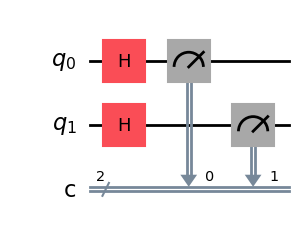

In [32]:
# Now measurement. This time we construct the measurement part
# of the circuit separately and then combine it with the first circuit.

# A new circuit with 2 qubits and 2 classical bits
meas = QuantumCircuit(2, 2)

# Map the quantum measurement to the classical bits
meas.measure(range(2), range(2))

# The Qiskit circuit object supports composition.
# Here the meas has to be first and front=True (putting it before)
# as compose must put a smaller circuit into a larger one.
qc = meas.compose(circuit, range(2), front=True)

qc.draw("mpl")

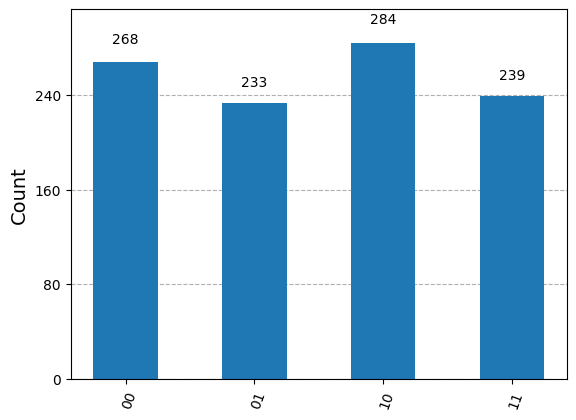

In [33]:
# Simulate again, using the same back end
qc_compiled = transpile(qc, backend)
job_sim = backend.run(qc_compiled, shots=1024)
result_sim = job_sim.result()
counts = result_sim.get_counts(qc_compiled)
plot_histogram(counts)

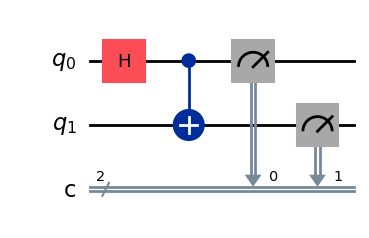

In [34]:
# Now for some entanglement.
# Construct a Bell state and measure both qubits to see that
# both measurements give the same result.

circuit = QuantumCircuit(2,2)
circuit.h(0)
circuit.cx(0,1) # cx means CNOT because it's a controlled version of x (negation)
circuit.measure(range(2),range(2))
circuit.draw("mpl")

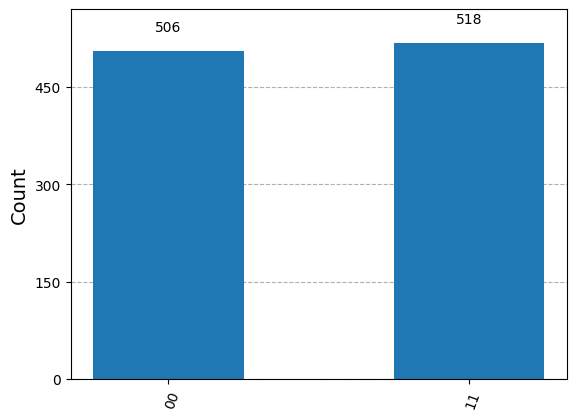

In [35]:
qc_compiled = transpile(circuit, backend)
job_sim = backend.run(qc_compiled, shots=1024)
result_sim = job_sim.result()
counts = result_sim.get_counts(qc_compiled)
plot_histogram(counts)

In [36]:
# EXERCISE

# Make a copy here of the circuit that creates the Bell state 1/sqrt(2) ( |00> + |11> ).

# Modify it to create the other Bell states: 1/sqrt(2) ( |00> - |11> ), 1/sqrt(2) ( |01> + |10> ), 1/sqrt(2) ( |01> - |10> ).

# You will need to use X and Z gates. Check that your circuit is correct by displaying the state vector in each case.

# For each of the Bell states, repeat the simulation with measurements and check that the results are as expected.

Φ+ = 1/sqrt(2) ( |00> + |11> )


<IPython.core.display.Latex object>

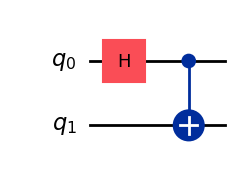

Φ- = 1/sqrt(2) ( |00> - |11> )


<IPython.core.display.Latex object>

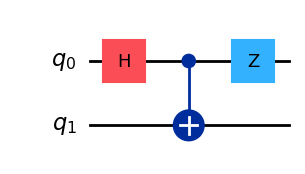

Ψ+ = 1/sqrt(2) ( |01> + |10> )


<IPython.core.display.Latex object>

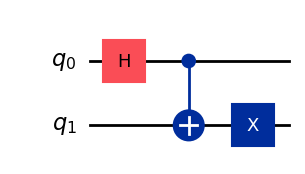

Ψ- = 1/sqrt(2) ( |01> - |10> )


<IPython.core.display.Latex object>

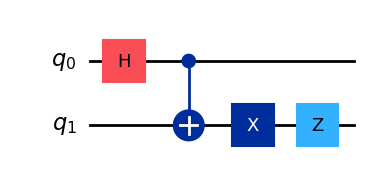

In [37]:
# Bell state 1: |Φ+⟩ = 1/sqrt(2) ( |00> + |11> )
bell1 = QuantumCircuit(2)
bell1.h(0)
bell1.cx(0, 1)

print("Φ+ = 1/sqrt(2) ( |00> + |11> )")
display(Statevector.from_int(0, 4).evolve(bell1).draw("latex"))
display(bell1.draw("mpl"))

# Bell state 2: |Φ-⟩ = 1/sqrt(2) ( |00> - |11> )
# Z on q0 flips the phase of |11> (q0=1 in |11>)
bell2 = QuantumCircuit(2)
bell2.h(0)
bell2.cx(0, 1)
bell2.z(0)

print("Φ- = 1/sqrt(2) ( |00> - |11> )")
display(Statevector.from_int(0, 4).evolve(bell2).draw("latex"))
display(bell2.draw("mpl"))

# Bell state 3: |Ψ+⟩ = 1/sqrt(2) ( |01> + |10> )
# X on q1 swaps |00>↔|10> and |11>↔|01>
bell3 = QuantumCircuit(2)
bell3.h(0)
bell3.cx(0, 1)
bell3.x(1)

print("Ψ+ = 1/sqrt(2) ( |01> + |10> )")
display(Statevector.from_int(0, 4).evolve(bell3).draw("latex"))
display(bell3.draw("mpl"))

# Bell state 4: |Ψ-⟩ = 1/sqrt(2) ( |01> - |10> )
# X on q1 swaps the basis; Z on q1 then flips phase of |10> (q1=1)
bell4 = QuantumCircuit(2)
bell4.h(0)
bell4.cx(0, 1)
bell4.x(1)
bell4.z(1)

print("Ψ- = 1/sqrt(2) ( |01> - |10> )")
display(Statevector.from_int(0, 4).evolve(bell4).draw("latex"))
display(bell4.draw("mpl"))

Φ+ = 1/sqrt(2)(|00>+|11>)


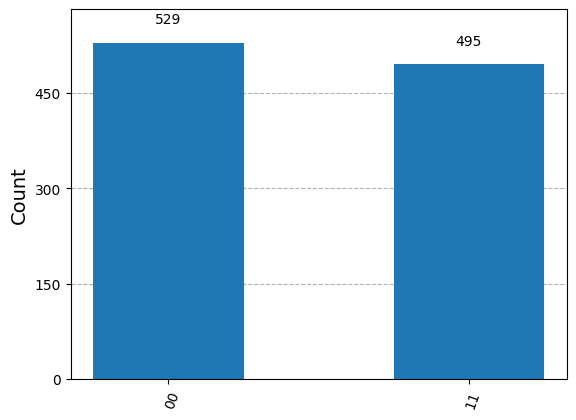

Φ- = 1/sqrt(2)(|00>-|11>)


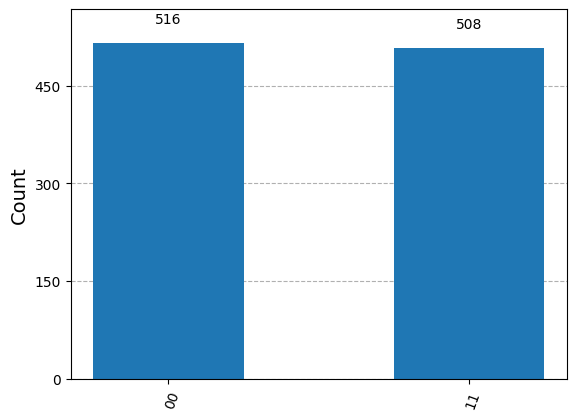

Ψ+ = 1/sqrt(2)(|01>+|10>)


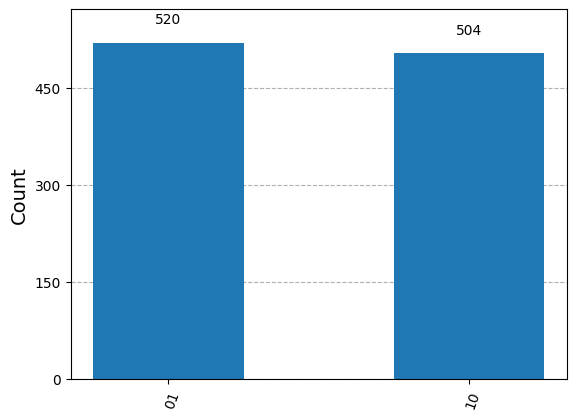

Ψ- = 1/sqrt(2)(|01>-|10>)


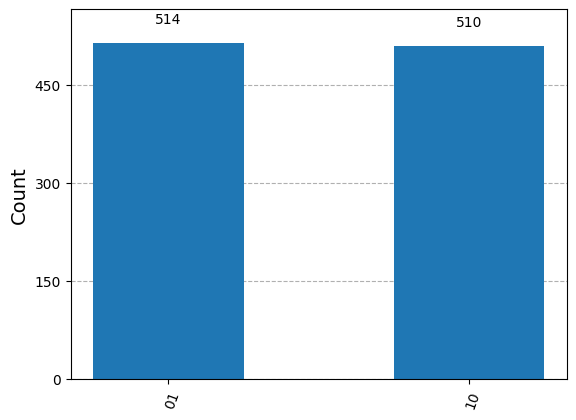

In [38]:
# Simulate measurements for all four Bell states
# Φ± should give |00> and |11> with ~50% each
# Ψ± should give |01> and |10> with ~50% each

backend = BasicSimulator()
bell_circuits = [bell1, bell2, bell3, bell4]
bell_names = [
    "Φ+ = 1/sqrt(2)(|00>+|11>)",
    "Φ- = 1/sqrt(2)(|00>-|11>)",
    "Ψ+ = 1/sqrt(2)(|01>+|10>)",
    "Ψ- = 1/sqrt(2)(|01>-|10>)",
]

for circ, name in zip(bell_circuits, bell_names):
    meas_circ = QuantumCircuit(2, 2)
    meas_circ.compose(circ, inplace=True)
    meas_circ.measure(range(2), range(2))

    qc_compiled = transpile(meas_circ, backend)
    counts = backend.run(qc_compiled, shots=1024).result().get_counts(qc_compiled)
    print(name)
    display(plot_histogram(counts))

In [39]:
# EXERCISE

# The GHZ state on any number of qubits has the form  1/sqrt(2) ( |00...0> + |11...1> )

# The Bell state 1/sqrt(2) ( |00> + |11> ) is the case for two qubits.

# Write code to construct a circuit that produces a GHZ state for any given number of qubits.

# Try simulating the circuit, with measurements. How many qubits can the simulator handle in a reasonable time?

GHZ state for 3 qubits:


<IPython.core.display.Latex object>

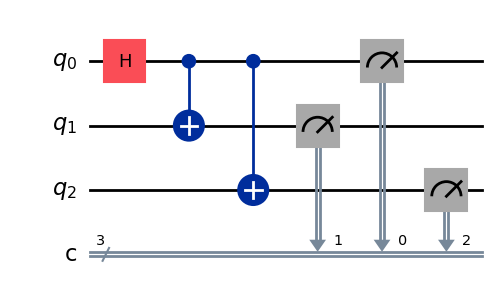

In [40]:
import time

def ghz_circuit(n_qubits):
    """Build a GHZ state: 1/sqrt(2) ( |00...0> + |11...1> ) for n_qubits."""
    qc = QuantumCircuit(n_qubits, n_qubits)
    qc.h(0)                         # put qubit 0 into superposition
    for i in range(1, n_qubits):
        qc.cx(0, i)                 # entangle every other qubit with qubit 0
    qc.measure(range(n_qubits), range(n_qubits))
    return qc

# Verify state vector for the 3-qubit case (without measurement)
ghz3_sv = QuantumCircuit(3)
ghz3_sv.h(0)
ghz3_sv.cx(0, 1)
ghz3_sv.cx(0, 2)

print("GHZ state for 3 qubits:")
display(Statevector.from_int(0, 8).evolve(ghz3_sv).draw("latex"))
display(ghz_circuit(3).draw("mpl"))

In [41]:
# How many qubits can the simulator handle in a reasonable time?
# Results should only ever show all-zeros or all-ones bitstrings.
backend = BasicSimulator()

for n in [2, 3, 5, 10, 15, 20]:
    qc = ghz_circuit(n)
    qc_compiled = transpile(qc, backend)

    t0 = time.time()
    counts = backend.run(qc_compiled, shots=1024).result().get_counts(qc_compiled)
    elapsed = time.time() - t0

    zeros = counts.get("0" * n, 0)
    ones  = counts.get("1" * n, 0)
    print(f"n={n:2d}  |{'0'*n}>={zeros:4d}  |{'1'*n}>={ones:4d}  time={elapsed:.3f}s")

n= 2  |00>= 509  |11>= 515  time=0.008s
n= 3  |000>= 520  |111>= 504  time=0.005s
n= 5  |00000>= 536  |11111>= 488  time=0.017s
n=10  |0000000000>= 503  |1111111111>= 521  time=0.013s
n=15  |000000000000000>= 544  |111111111111111>= 480  time=0.076s
n=20  |00000000000000000000>= 517  |11111111111111111111>= 507  time=4.742s
